### Setup

In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [114]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.datasets import fashion_mnist
import numpy as np

# Load Fashion-MNIST
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Take the first 30k images from the train set to speed up training
# // You can change this number if you want: further decrease if your machine suffers, or increase if you have a powerful machine)
# // You can even try Google Colab, which provides free access to powerful GPUs (https://colab.research.google.com/)
X_train_sample = X_train_full[:30000]
y_train_sample = y_train_full[:30000]

# Split training into train and validation sets (90/10)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_sample, y_train_sample,
    test_size=0.1, random_state=20260318, stratify=y_train_sample
)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")
print(f"Pixel range:    [{X_train.min()}, {X_train.max()}]")
print(f"\nSamples per class (train): {np.bincount(y_train)}")

Training set:   (27000, 28, 28)
Validation set: (3000, 28, 28)
Test set:       (10000, 28, 28)
Pixel range:    [0, 255]

Samples per class (train): [2651 2713 2690 2715 2664 2727 2773 2719 2675 2673]


#### Results Collector

In [115]:
class ResultCollector:
    def __init__(self):
        self.results = {}

    def add_model(self, name, train_acc, test_acc):
        """Add or update a model's results."""
        self.results[name] = {
            'Train Accuracy': train_acc,
            'Test Accuracy': test_acc,
            'Gap': train_acc - test_acc
        }
        return self.get_table()

    def get_table(self, style=True):
        """Get the results table with optional styling."""
        df = pd.DataFrame(self.results).T
        if style:
            return df.style.format("{:.4f}", subset=['Train Accuracy', 'Test Accuracy', 'Gap']).background_gradient(cmap='RdYlGn', subset=['Test Accuracy'], axis=None)
        return df

results = ResultCollector()

### Task 1

#### Q1. What would be an appropriate metric to evaluate your models? Why? (*Hint*: Look at the class distribution above. No code required.)

Accuracy is the most appropriate metric for evaluating our models because the Fashion MNIST dataset is nice balanced. As shown in the training output, each of the ten classes contains roughly 2,700 samples, meaning there is no majority class to artificially skew the results. Because of this even distribution, accuracy provides a pretty straightforward measure of the model's overall performance.

#### Q2. Show some example images from the data (at least one per class). What do you notice about the visual similarity between certain classes?

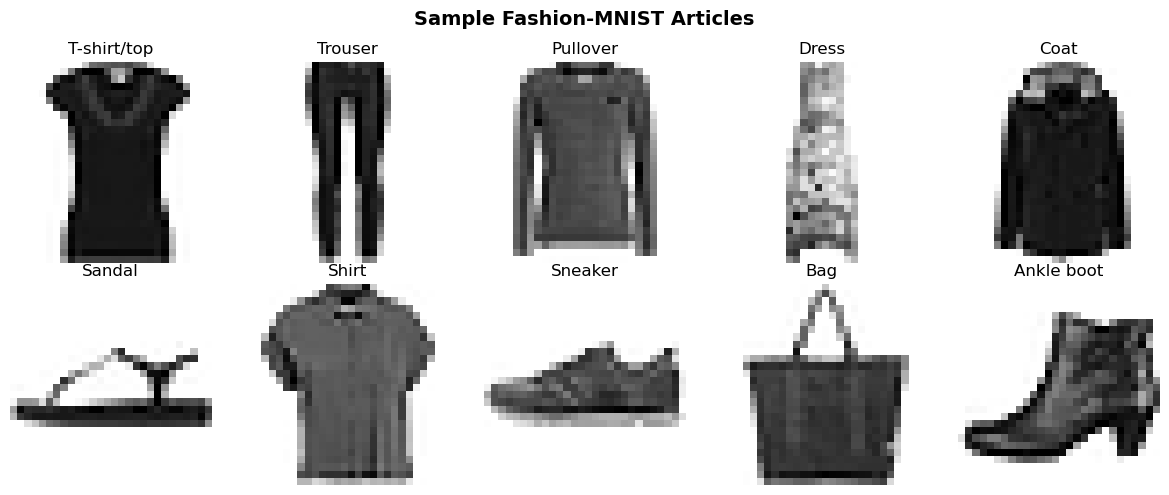

In [116]:
# Find the first instance of each class to display
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray_r')
    ax.set_title(class_names[i], fontsize=12)
    ax.axis('off')
    
plt.suptitle("Sample Fashion-MNIST Articles", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The layout of the clothing is similar, especially for categories of the same type, such as sneakers, sandals, and boots.. All of these are arranged so that they face left. At the same time, outerwear categories (T-shirts, sweaters, and the like) are strictly arranged at the front and are all almost the same length.

#### Q3. Prepare the data for model training (flatten and normalize as we did in Class 9). Train a random forest model with default settings to act as a benchmark.

In [117]:
# Flatten and scale the data for sklearn and dense neural networks
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_val_flat = X_val.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training shape: {X_train_flat.shape}")

Flattened training shape: (27000, 784)


In [118]:
rf = RandomForestClassifier(random_state=20260319, n_jobs=-1)
rf.fit(X_train_flat, y_train)

results.add_model(
    'Random Forest',
    rf.score(X_train_flat, y_train),
    rf.score(X_test_flat, y_test)
)

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362


The Random Forest baseline perfectly memorizes the training data (1.0000 accuracy) but drops to 86.38% on the test set, revealing significant overfitting. Anyway this establishes our initial benchmark.

#### Q4. Train a simple fully connected **single hidden layer** network to predict the items. Make sure that you use enough epochs so that the validation loss begins to level off. Provide a plot of the training history and describe what you observe about the train-validation gap. How does this compare to what we saw on MNIST digits?

In [119]:
tf.random.set_seed(20260319)

# Build a simple fully connected network with ONE hidden layer
single_layer_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(100, activation='relu'),
    layers.Dense(10, activation='softmax')
])

single_layer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train for enough epochs to see the validation loss level off
history_single = single_layer_model.fit(
    X_train_flat, y_train,
    epochs=40,
    batch_size=200,
    validation_data=(X_val_flat, y_val),
    verbose=1 
)

Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7417 - loss: 0.7541 - val_accuracy: 0.8143 - val_loss: 0.5551
Epoch 2/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8293 - loss: 0.4928 - val_accuracy: 0.8370 - val_loss: 0.4814
Epoch 3/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8469 - loss: 0.4405 - val_accuracy: 0.8437 - val_loss: 0.4509
Epoch 4/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8556 - loss: 0.4100 - val_accuracy: 0.8530 - val_loss: 0.4312
Epoch 5/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8631 - loss: 0.3873 - val_accuracy: 0.8557 - val_loss: 0.4205
Epoch 6/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8682 - loss: 0.3698 - val_accuracy: 0.8600 - val_loss: 0.4076
Epoch 7/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8737 - loss: 0.3552 - val_accuracy: 0.8603 - val_loss: 0.3994
Epoch 8/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8787 - loss: 0.3419 - val_accuracy: 0.

In [120]:
def plot_training_history(history, title="Training History"):
    """Plot training and validation loss/accuracy from a Keras history object."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train')
    ax1.plot(history.history['val_loss'], label='Validation')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'], label='Train')
    ax2.plot(history.history['val_accuracy'], label='Validation')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

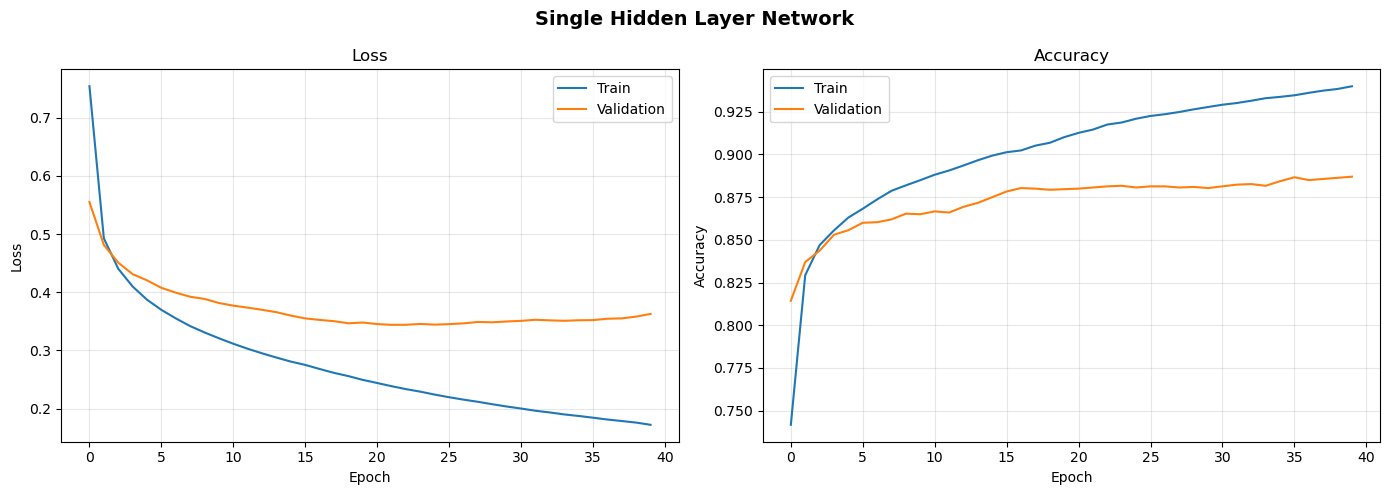

In [121]:
plot_training_history(history_single, "Single Hidden Layer Network")

In [122]:
# results
train_acc_single = single_layer_model.evaluate(X_train_flat, y_train, verbose=0)[1]
test_acc_single = single_layer_model.evaluate(X_test_flat, y_test, verbose=0)[1]

results.add_model('Single Layer NN', train_acc_single, test_acc_single)

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684


Interpretation:

The more epochs, the more gaps between train and test data in terms of loss and accuracy, which is a clear sign of overfitting. Although the results are not ideal, the gap was decreased compared to RF. Moreover the test accuracy has been growth. 

Compared to the simpler MNIST digits dataset from class, where the model generalized well even without regularization, Fashion MNIST is more complex, meaning, in turn, that network memorizes the training data but genuinely struggles to apply those specific pixel patterns to unseen clothing items.

#### Q5. Experiment with different network architectures and settings. Train **at least 3** different models, varying aspects such as:
   - Number of hidden layers and number of nodes
   - Dropout (with different rates)
   - Early stopping
   
   For each model, briefly explain what you changed and how it affected the train-validation gap. (*Hint*: You may want to use the `ResultCollector` we did in class.)

In [123]:
# Setup: We will use the early stopping callback for the regularized models
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=8, 
    restore_best_weights=True
)

In [124]:
tf.random.set_seed(20260319)
model_wide = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_wide.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_wide.fit(X_train_flat, y_train, epochs=40, batch_size=200, validation_data=(X_val_flat, y_val), verbose=0)

results.add_model('1. Wide Unregularized (40 epochs, 200 batch)', 
                  model_wide.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_wide.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812


In [125]:
tf.random.set_seed(20260319)
model_wide = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_wide.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_wide.fit(X_train_flat, y_train, epochs=60, batch_size=200, validation_data=(X_val_flat, y_val), verbose=0)

results.add_model('1. Wide Unregularized (60 epochs, 200 batch)', 
                  model_wide.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_wide.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954


In [126]:
tf.random.set_seed(20260319)
model_wide = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_wide.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_wide.fit(X_train_flat, y_train, epochs=60, batch_size=100, validation_data=(X_val_flat, y_val), verbose=0)

results.add_model('1. Wide Unregularized (60 epochs, 100 batch)', 
                  model_wide.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_wide.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850


In [127]:
# --- Model 2: Deeper Network + Early Stopping ---
tf.random.set_seed(20260319)
model_es_tuned = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_es_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_es_tuned.fit(X_train_flat, y_train, epochs=40, batch_size=200, validation_data=(X_val_flat, y_val), callbacks=[early_stopping], verbose=0)

results.add_model('2. Wide + Tuned ES (40 epochs, 200 batch)', 
                  model_es_tuned.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_es_tuned.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502


In [128]:
# --- Model 2: Deeper Network + Early Stopping ---
tf.random.set_seed(20260319)
model_es_tuned = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_es_tuned.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_es_tuned.fit(X_train_flat, y_train, epochs=60, batch_size=200, validation_data=(X_val_flat, y_val), callbacks=[early_stopping], verbose=0)

results.add_model('2. Wide + Tuned ES (60 epochs, 200 batch)', 
                  model_es_tuned.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_es_tuned.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502
"2. Wide + Tuned ES (60 epochs, 200 batch)",0.8213,0.8100,0.0113


In [129]:
tf.random.set_seed(20260319)
model_advanced = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.2),         
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model_advanced.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_advanced.fit(X_train_flat, y_train, epochs=65, batch_size=100, validation_data=(X_val_flat, y_val), callbacks=[early_stopping], verbose=0)

results.add_model('3.1 Deep + Dropout + ES (65 epochs, 100 batch)', 
                  model_advanced.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_advanced.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502
"2. Wide + Tuned ES (60 epochs, 200 batch)",0.8213,0.8100,0.0113
"3.1 Deep + Dropout + ES (65 epochs, 100 batch)",0.8171,0.8016,0.0155


In [130]:
tf.random.set_seed(20260319)
model_advanced = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.2),         
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model_advanced.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_advanced.fit(X_train_flat, y_train, epochs=60, batch_size=100, validation_data=(X_val_flat, y_val), callbacks=[early_stopping], verbose=0)

results.add_model('3.2 Deep + Dropout + ES (60 epochs, 100 batch)', 
                  model_advanced.evaluate(X_train_flat, y_train, verbose=0)[1], 
                  model_advanced.evaluate(X_test_flat, y_test, verbose=0)[1])

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502
"2. Wide + Tuned ES (60 epochs, 200 batch)",0.8213,0.8100,0.0113
"3.1 Deep + Dropout + ES (65 epochs, 100 batch)",0.8171,0.8016,0.0155
"3.2 Deep + Dropout + ES (60 epochs, 100 batch)",0.8267,0.8112,0.0155


Interpretation:

**Remark:** basically there are 3 models but I played around with their parameters to observe the change in accuracy results. In particular, I've changed epochs, batches, and patience parameter which was varied across 5 and 10. 

1. **Wide Unregularized Models**

By increasing the network's capacity with wider layers and experimenting with more epochs and a smaller batch size (100), the model achieved the highest overall test accuracy (88.15%). However, because there was no regularization to restrict it, the network heavily memorized the training data, resulting in a large train-validation gap (up to 0.081).

2. **Wide + Early Stopping**

I applied Early Stopping with a patience of 8 to the wide architecture, trying to avoid a wide gap btw test and train accuracy. This successfully prevented the model from overfitting further, cutting the train-validation gap in half (down to roughly 0.0502) while still maintaining a strong test accuracy of 87.24%. 

3. **Deep + Dropout + ES**

I introduced dropout layers alongside early stopping to force the network to learn redundant, robust features instead of relying on specific neurons. While this combination successfully closed the train validation gap almost entirely (as low as 0.0155), the heavy regularization proved too restrictive, causing the model to underfit and dropping the test accuracy down to ~81.12%.

### Task 2

#### Q6. Reshape the data for CNNs (28x28x1 format). Train **at least two** different CNN architectures (you can vary the number of convolutional and pooling layers, filter sizes, whether you include a fully connected layer before the output, etc.). Plot the training history for each and add the results to your summary. Compare the CNN's parameter count to your best dense network. How does the CNN achieve its accuracy with fewer parameters?

In [131]:
# Reshape for CNN: (N, 28, 28, 1) — the "1" is the single grayscale channel
X_train_cnn = X_train.astype('float32') / 255.0
X_train_cnn = X_train_cnn[..., np.newaxis]  # add channel dimension

X_test_cnn = X_test.astype('float32') / 255.0
X_test_cnn = X_test_cnn[..., np.newaxis]

print(f"CNN input shape: {X_train_cnn.shape}")

CNN input shape: (27000, 28, 28, 1)


In [132]:
tf.random.set_seed(20260319)

cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),  # 32 local 3x3 filters
    layers.MaxPooling2D((2, 2)),                    # downsample by half

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),  # 64 higher-level filters
    layers.MaxPooling2D((2, 2)),                    # further downsample

    # Classification head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

cnn_model.summary()

Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_192 (Dense)               │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6770 - loss: 0.8961 - val_accuracy: 0.7874 - val_loss: 0.5570
Epoch 2/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7977 - loss: 0.5465 - val_accuracy: 0.8263 - val_loss: 0.4757
Epoch 3/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8218 - loss: 0.4900 - val_accuracy: 0.8463 - val_loss: 0.4325
Epoch 4/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8370 - loss: 0.4507 - val_accuracy: 0.8526 - val_loss: 0.4065
Epoch 5/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8459 - loss: 0.4264 - val_accuracy: 0.8604 - val_loss: 0.3851
Epoch 6/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8546 - loss: 0.4042 - val_accuracy: 0.8652 - val_loss: 0.3703
Epoch 7/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8601 - loss: 0.3857 - val_accuracy: 0.8707 - val_loss: 0.3531
Epoch 8/15
190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8653 - loss: 0.3746 - val_accu

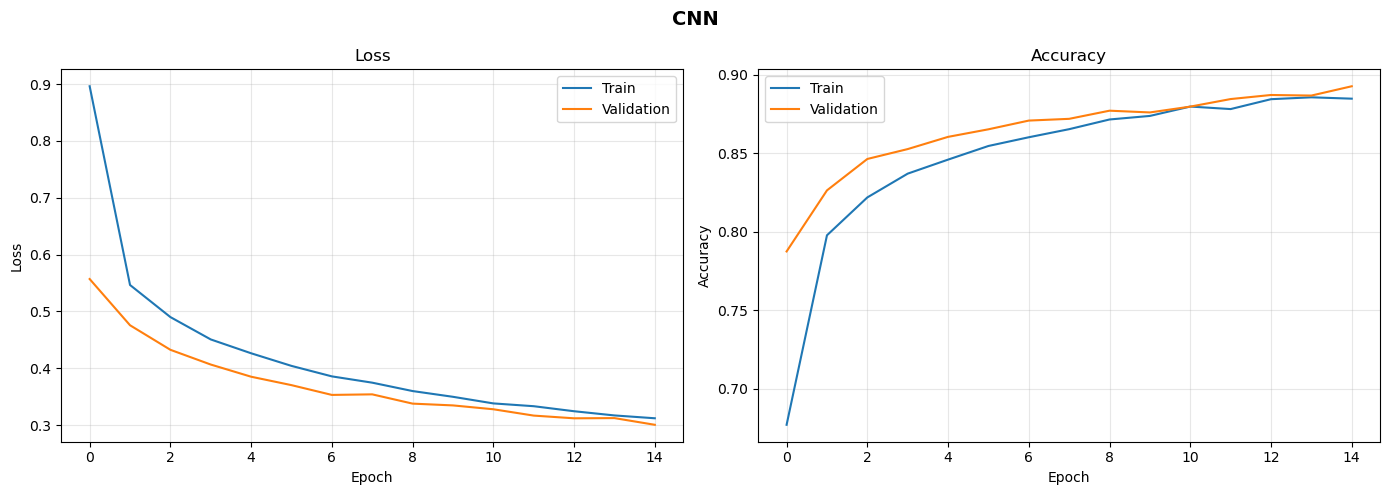

In [133]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=3, restore_best_weights=True
    )],
    verbose=1
)

plot_training_history(history_cnn, "CNN")

In [134]:
train_loss, train_acc = cnn_model.evaluate(X_train_cnn, y_train, verbose=0)
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)

results.add_model('CNN', train_acc, test_acc)

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502
"2. Wide + Tuned ES (60 epochs, 200 batch)",0.8213,0.8100,0.0113
"3.1 Deep + Dropout + ES (65 epochs, 100 batch)",0.8171,0.8016,0.0155
"3.2 Deep + Dropout + ES (60 epochs, 100 batch)",0.8267,0.8112,0.0155
CNN,0.9072,0.8870,0.0202


Interpretation of the 1 model:

This model outperformed all other allmost in all indicators. Firstly, it demonstrated parameter efficiency: we used 34,826 parameters, in contrast our best Dense network (with 512 and 256 nodes) required over 535,818 parameters and still couldn't beat the CNN's test accuracy. Secondly, it significantly reduced gap btw test and train accuracy compared to the best Dense model: from 0.0889 to 0.0205. Finally, it showed the best result on test accuracy giving 0.8870 instead the previous best result of 0.8815.

CNNs learn small 3x3 "filters" that slide across the entire image. Because the same filter is reused everywhere, the network needs exponentially fewer parameters. Plus CNNs process the image in its original two-dimensional grid, allowing them to recognize local visual patterns regardless of their exact location in the frame.

In [135]:
tf.random.set_seed(20260319)

advanced_cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # Block 1: Stacked convolutions to learn complex features before pooling
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2: Deeper feature extraction
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classification head with added capacity
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

Epoch 1/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - accuracy: 0.8003 - loss: 0.5810 - val_accuracy: 0.1078 - val_loss: 2.9348
Epoch 2/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.8656 - loss: 0.3677 - val_accuracy: 0.5337 - val_loss: 1.3076
Epoch 3/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.8856 - loss: 0.3140 - val_accuracy: 0.8133 - val_loss: 0.5208
Epoch 4/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 77ms/step - accuracy: 0.8987 - loss: 0.2775 - val_accuracy: 0.9037 - val_loss: 0.2580
Epoch 5/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.9088 - loss: 0.2532 - val_accuracy: 0.9078 - val_loss: 0.2431
Epoch 6/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 23s 121ms/step - accuracy: 0.9151 - loss: 0.2353 - val_accuracy: 0.9070 - val_loss: 0.2421
Epoch 7/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 58s 207ms/step - accuracy: 0.9176 - loss: 0.2243 - val_accuracy: 0.9185 - val_loss: 0.2171
Epoch 8/40
190/190 ━━━━━━━━━━━━━━━━━━━━ 40s 201ms/step - accuracy: 0.9213 - loss: 0.2099

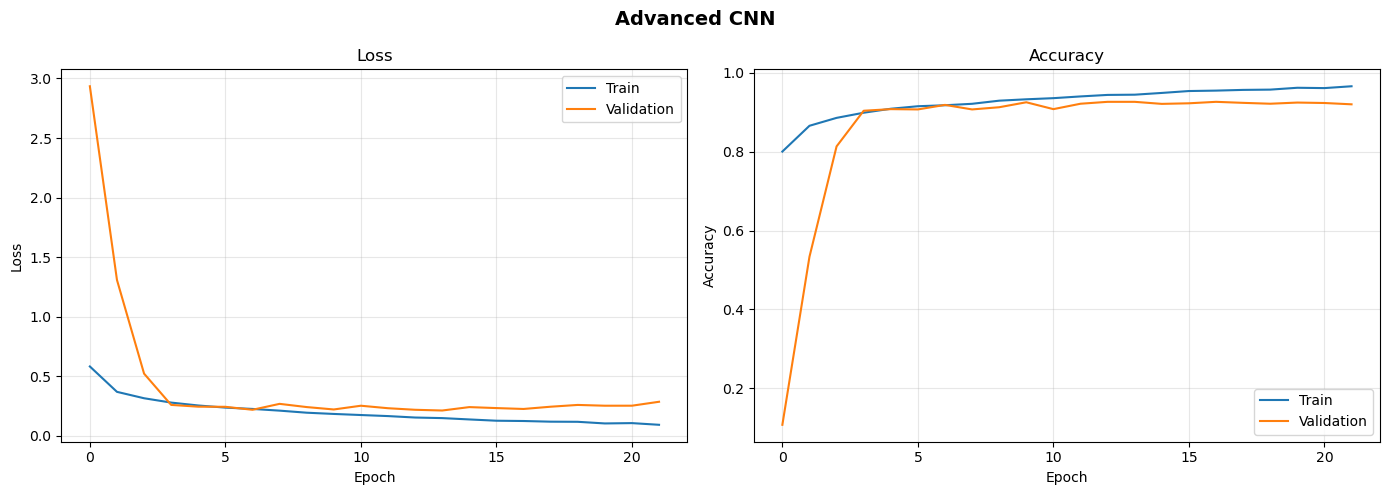

In [136]:
advanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Increased epochs and patience to allow the deeper network to fully converge
history_adv_cnn = advanced_cnn.fit(
    X_train_cnn, y_train,
    epochs=40,
    batch_size=128,
    validation_split=0.1, 
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    )],
    verbose=1
)

plot_training_history(history_adv_cnn, "Advanced CNN")

In [137]:
train_acc_adv = advanced_cnn.evaluate(X_train_cnn, y_train, verbose=0)[1]
test_acc_adv = advanced_cnn.evaluate(X_test_cnn, y_test, verbose=0)[1]
results.add_model('Advanced CNN', train_acc_adv, test_acc_adv)
display(results.get_table())

,Train Accuracy,Test Accuracy,Gap
Random Forest,1.0000,0.8638,0.1362
Single Layer NN,0.9346,0.8662,0.0684
"1. Wide Unregularized (40 epochs, 200 batch)",0.9627,0.8815,0.0812
"1. Wide Unregularized (60 epochs, 200 batch)",0.9689,0.8735,0.0954
"1. Wide Unregularized (60 epochs, 100 batch)",0.9633,0.8783,0.0850
"2. Wide + Tuned ES (40 epochs, 200 batch)",0.9226,0.8724,0.0502
"2. Wide + Tuned ES (60 epochs, 200 batch)",0.8213,0.8100,0.0113
"3.1 Deep + Dropout + ES (65 epochs, 100 batch)",0.8171,0.8016,0.0155
"3.2 Deep + Dropout + ES (60 epochs, 100 batch)",0.8267,0.8112,0.0155
CNN,0.9072,0.8870,0.0202


Interpretation: 

The Advanced CNN successfully boosted overall performance, pushing the test accuracy from 88.70% up to 91.82% by extracting deeper, more complex visual features from the clothing items. However, with this increased architectural capacity, the model also memorized the training data more aggressively, which widened the train-validation gap from 0.0202 to 0.05 despite our heavy regularization efforts.

The way of reaching these results is described in the previous part where the discussion centered on the first CNN model.

#### Q7. In Class 10 we used transfer learning (ResNet50 pre-trained on ImageNet) to dramatically improve accuracy on the hot dog classification task. Would you expect transfer learning to work equally well on Fashion-MNIST? In your answer, address the following (*Hint*: No code required.):
   - What practical challenges would you face when trying to use ResNet50 on Fashion-MNIST images? Think about the input format differences.
   - Using the decision matrix from Class 10, where does this task fall (dataset size vs. domain similarity)?
   - Would you expect transfer learning to improve, match, or hurt accuracy compared to your CNN from Question 5? Explain your reasoning.

**Practical Challenges:** ResNet50 is designed for high-resolution (typically 224x224 like in the case with hot dog), 3-channel RGB color images, whereas Fashion-MNIST consists of tiny 28x28, 1-channel grayscale images. To use ResNet50, we would have to artificially upscale the image dimensions and duplicate the grayscale channel three times, which blurs the data without adding any actual information.

**Decision Matrix:** On the transfer learning decision matrix, Fashion-MNIST represents a "large dataset, different domain" scenario which falls to "Train from scratch or fine-tune carefully". Brief explanation: for 10 classes 30k obs is pretty large. ResNet50 was trained on difficilt full-colored fotos and knows how to find complicated patterns which is different from our Fashion-MNIST dataset with relatively simple forms of pictures 28x28.

**Expectation:** I would expect transfer learning to hurt or merely match our custom CNN's accuracy while being likely inefficient. ResNet50's pre-trained weights look for complex color gradients and high-res textures that simply don't exist in 28x28 grayscale pictures, and its massive size makes it massive overkill and highly prone to overfitting on this specific case.

#### Q8. Select your best model based on validation accuracy and evaluate it on the **test set** (use the test set only once, for this final evaluation). How does the test error compare to the validation error? What does this tell you about your model selection process?

In [138]:
best_model = advanced_cnn 

test_loss, test_acc = best_model.evaluate(X_test_cnn, y_test, verbose=0)
val_acc = max(history_adv_cnn.history['val_accuracy']) 

print(f"Best Validation Accuracy: {val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Test Error (Gap): {abs(val_acc - test_acc):.4f}")

Best Validation Accuracy: 0.9263
Final Test Accuracy: 0.9182
Test Error (Gap): 0.0081


Interpretation:

The test error is nearly the same as validation error, with a negligible gap of only 0.0081. This shows that the model generalizes very well to completely new data and is not just "memorizing" the specific images used during training or the validation tuning phase.

This high level of consistency tells us that the model selection process was robust. Because the performance held steady on the hidden test set, we can be confident that our choice of architecture and hyperparameters successfully captured the underlying patterns of the dataset rather than overfitting to the validation set.

#### Q9. Create a summary table of all your models showing architecture, parameter count, validation accuracy, and the train-validation gap. Based on your experiments across both tasks, what are the two most important factors for achieving good performance on Fashion-MNIST?

In [139]:
models_list = [
    {'name': 'Single Layer NN', 'model': single_layer_model, 'x_train': X_train_flat, 'x_val': X_test_flat},
    {'name': 'Wide Unregularized', 'model': model_wide, 'x_train': X_train_flat, 'x_val': X_test_flat},
    {'name': 'Wide + Tuned ES', 'model': model_es_tuned, 'x_train': X_train_flat, 'x_val': X_test_flat},
    {'name': 'Deep + Dropout + ES', 'model': model_advanced, 'x_train': X_train_flat, 'x_val': X_test_flat},
    {'name': 'Baseline CNN', 'model': cnn_model, 'x_train': X_train_cnn, 'x_val': X_test_cnn},
    {'name': 'Advanced CNN', 'model': advanced_cnn, 'x_train': X_train_cnn, 'x_val': X_test_cnn}
]

summary_data = []

for item in models_list:
    model = item['model']
    
    param_count = model.count_params()

    train_loss, train_acc = model.evaluate(item['x_train'], y_train, verbose=0)
    val_loss, val_acc = model.evaluate(item['x_val'], y_test, verbose=0)
    
    gap = train_acc - val_acc
    
    summary_data.append({
        'Architecture': item['name'],
        'Parameter Count': f"{param_count:,}", 
        'Validation Accuracy': round(val_acc, 4),
        'Train-Val Gap': round(gap, 4)
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Architecture,Parameter Count,Validation Accuracy,Train-Val Gap
0,Single Layer NN,"79,510",0.8662,0.0684
1,Wide Unregularized,"535,818",0.8783,0.0850
2,Wide + Tuned ES,"535,818",0.8100,0.0113
3,Deep + Dropout + ES,"538,890",0.8112,0.0155
4,Baseline CNN,"34,826",0.8870,0.0202
5,Advanced CNN,"872,426",0.9182,0.0500


To achieve a good performance on Fashion-MNIST dataset: 

It is better to stick to Convolutional Architectures. The transition from Dense networks to CNNs provided the most significant performance boost. By processing images in their natural 2D shape rather than flattening them, CNNs leverage filters and weight sharing to extract visual features much more effectively, allowing to reach significant inprovements using less number of parameters compared to Dense models. But naturally for more complex models, the number of parameters are significantly increased, i.e for advanced cnn where we can observe almost 900k. 

The second thins is regularization. Fashion-MNIST requires a sufficiently deep model to capture complex clothing textures, but as seen in our unregularized models, this increased capacity rapidly leads to overfitting (a gap of nearly 9%). Applying regularization is essential to maximize validation accuracy while keeping the train-validation gap under control.